In [2]:
import sys
import importlib
import os
print('Python:', sys.version)
print('Executable:', sys.executable)

for name in ['pandas', 'openpyxl', 'seaborn', 'pywt']:
    try:
        m = importlib.import_module(name)
        ver = getattr(m, '__version__', 'unknown')
        print(f'OK: {name} {ver}')
    except Exception as e:
        print(f'MISSING/ERROR: {name}: {type(e).__name__}: {e}')


Python: 3.11.14 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 18:30:03) [MSC v.1929 64 bit (AMD64)]
Executable: d:\miniconda\envs\machine\python.exe
OK: pandas 2.3.3
OK: openpyxl 3.1.5
OK: seaborn 0.13.2
OK: pywt 1.8.0


In [3]:
from pathlib import Path
import pandas as pd
import numpy as np

DATA_DIR = Path('e:/desk_top/a/quick')
BAD_DIR = DATA_DIR / 'bad'
GOOD_DIR = DATA_DIR / 'good'

bad_files = sorted(BAD_DIR.glob('*.xlsx'))
good_files = sorted(GOOD_DIR.glob('*.xlsx'))

print('bad:', len(bad_files), 'files')
print('good:', len(good_files), 'files')
print('example bad:', bad_files[0].name if bad_files else None)
print('example good:', good_files[0].name if good_files else None)

def read_egg_xlsx(path: Path) -> np.ndarray:
    """读取一个蛋的敲击响应波形。

    约定：前2列=大端敲击，后2列=小端敲击；采样率 48kHz。
    返回 shape=(n_samples, 4) 的 float64 数组。
    """
    df = pd.read_excel(path, engine='openpyxl', header=None)  # 无表头读入
    arr = df.to_numpy(dtype=np.float64)                      # 转成 float64 的 ndarray
    if arr.ndim != 2 or arr.shape[1] < 4:                    # 必须是二维且至少 4 列
        raise ValueError(f'{path.name}: expected >=4 columns, got shape {arr.shape}')
    return arr[:, :4]                                        # 只取前 4 列返回

def peek_xlsx(path: Path, n=5):
    # 读取指定 xlsx 并打印基本信息与前 n 行
    arr = read_egg_xlsx(path)
    print('\n==', path.name, '==')
    print('shape:', arr.shape)
    print('first rows:')
    print(arr[:n])
    return arr

# 快速查看首个坏蛋/好蛋文件的内容
if bad_files:
    arr_bad = peek_xlsx(bad_files[0])
if good_files:
    arr_good = peek_xlsx(good_files[0])


bad: 43 files
good: 30 files
example bad: 裂纹蛋1.xlsx
example good: 蛋1.xlsx

== 裂纹蛋1.xlsx ==
shape: (4800, 4)
first rows:
[[-1.277 -1.276 -1.275 -1.277]
 [-1.277 -1.276 -1.277 -1.275]
 [-1.28  -1.276 -1.275 -1.275]
 [-1.275 -1.275 -1.275 -1.273]
 [-1.276 -1.277 -1.275 -1.275]]

== 蛋1.xlsx ==
shape: (4800, 4)
first rows:
[[-1.28  -1.278 -1.277 -1.28 ]
 [-1.28  -1.278 -1.275 -1.278]
 [-1.278 -1.28  -1.279 -1.278]
 [-1.277 -1.278 -1.278 -1.277]
 [-1.278 -1.278 -1.279 -1.278]]


In [4]:
import math
from typing import Dict, Tuple, List

import numpy as np
from scipy import signal
from scipy.stats import skew, kurtosis

# ==============================================================
# 特征提取模块（用于“敲击响应信号 -> 机器学习特征向量”）
#
# 背景：每个鸡蛋文件包含 4 路波形：
#   - 前 2 列：大端敲击（2 个通道）
#   - 后 2 列：小端敲击（2 个通道）
#
# 目标：
#   1) 对每个端（大端/小端）分别提取一套“稳定且可对齐”的特征。
#   2) 每端包含 2 个通道：对每个通道提取同构特征后，
#      再对两通道做 mean/std 汇总，降低通道差异带来的波动。
#
# 注意：这里的特征全部是“手工统计特征”，适合小样本（几十个样本）场景。
# ==============================================================

FS = 48_000  # 采样率 Hz（每秒采样点数）

# 频带划分（用于频域带能量、STFT 频带统计）
BANDS_HZ = [
    (0, 500),
    (500, 2000),
    (2000, 5000),
    (5000, 10_000),
    (10_000, 20_000),
]


def _safe_div(a: float, b: float) -> float:
    """安全除法：避免 b=0 导致异常。

    说明：某些统计量（如 crest=peak/rms）在 rms=0 时会出现除零问题，
    这里统一返回 0.0 作为兜底。
    """
    return float(a) / float(b) if b != 0 else 0.0


def time_features(x: np.ndarray, prefix: str) -> Dict[str, float]:
    """提取时域统计特征（单通道）。

    参数
    - x: 1D 波形信号
    - prefix: 特征名前缀，用于区分大端/小端以及时域/频域/时频域等

    返回
    - Dict[str, float]: 该通道的时域特征字典

    细节
    - 先做零均值：去除直流偏置（传感器偏置、安装偏置等）
    - 偏度/峭度在 std=0（全零信号）时没有意义，因此做条件保护
    """
    x = np.asarray(x, dtype=np.float64)
    # 去均值（去直流），减少偏置对统计量影响
    x = x - np.mean(x)

    # RMS：能量强度的常用度量
    rms = float(np.sqrt(np.mean(x**2)))
    # peak：最大绝对幅值（冲击强度）
    peak = float(np.max(np.abs(x)))
    # ZCR：过零率（粗粒度反映信号振荡/频率成分）
    zc = float(np.mean((x[:-1] * x[1:]) < 0)) if x.size > 1 else 0.0

    feats = {
        # 注意：此处 mean 理论上接近 0（因为已去均值），保留是为了完整性
        f'{prefix}mean': float(np.mean(x)),
        f'{prefix}std': float(np.std(x, ddof=0)),
        f'{prefix}rms': rms,
        # ptp = max - min（峰峰值）
        f'{prefix}ptp': float(np.ptp(x)),
        f'{prefix}maxabs': peak,
        # 偏度/峭度：反映分布形态（冲击信号往往尖峰、长尾）
        f'{prefix}skew': float(skew(x, bias=False)) if np.std(x) > 0 else 0.0,
        f'{prefix}kurt': float(kurtosis(x, fisher=True, bias=False)) if np.std(x) > 0 else 0.0,
        f'{prefix}zcr': zc,
        # crest = peak / rms（波峰因子），越大说明“尖峰”越突出
        f'{prefix}crest': _safe_div(peak, rms),
        # energy：总能量（与 RMS 类似，但不做均值）
        f'{prefix}energy': float(np.sum(x**2)),
    }
    return feats


def spectral_features(x: np.ndarray, fs: int, prefix: str) -> Dict[str, float]:
    """提取频域统计特征（单通道，基于 Welch PSD）。

    方法
    - 使用 Welch 方法估计功率谱密度 PSD(f)：对短时/有噪信号更稳健
    - 在 PSD 上计算：谱质心、带宽、谱熵、主频、rolloff 等
    - 另外按预定义频带计算带功率（band power）

    参数
    - x: 1D 波形
    - fs: 采样率
    - prefix: 特征名前缀
    """
    x = np.asarray(x, dtype=np.float64)
    # 去均值减少 DC 分量对 PSD 的影响
    x = x - np.mean(x)

    # Welch：默认使用 Hann 窗；nperseg 不能超过信号长度
    freqs, psd = signal.welch(x, fs=fs, nperseg=min(1024, x.size), noverlap=None)
    # 数值安全：极少情况下 PSD 可能出现非常小的负值（数值误差）
    psd = np.maximum(psd, 0)
    p_sum = float(np.sum(psd))

    # 如果总谱能量接近 0（例如全零信号），所有频域统计量置 0
    if p_sum <= 0:
        centroid = 0.0
        bw = 0.0
        entropy = 0.0
        f_dom = 0.0
        rolloff = 0.0
    else:
        # 归一化为“概率分布”以计算熵/期望等统计量
        p_norm = psd / p_sum
        # 谱质心：频率的加权平均（能量集中位置）
        centroid = float(np.sum(freqs * p_norm))
        # 谱带宽：围绕质心的加权标准差（能量分散程度）
        bw = float(np.sqrt(np.sum(((freqs - centroid) ** 2) * p_norm)))
        # 谱熵：分布越“平坦”熵越大；越“集中”熵越小
        entropy = float(-np.sum(p_norm * np.log(p_norm + 1e-12)))
        # 主频：PSD 最大处的频率
        f_dom = float(freqs[int(np.argmax(psd))])
        # rolloff_85：累计能量达到 85% 时的频率
        cdf = np.cumsum(p_norm)
        rolloff = float(freqs[int(np.searchsorted(cdf, 0.85))])

    feats = {
        f'{prefix}spec_centroid': centroid,
        f'{prefix}spec_bw': bw,
        f'{prefix}spec_entropy': entropy,
        f'{prefix}f_dom': f_dom,
        f'{prefix}rolloff_85': rolloff,
    }

    # 分段频带能量（对 PSD 在对应频段积分）
    for lo, hi in BANDS_HZ:
        mask = (freqs >= lo) & (freqs < hi)
        # trapezoid：对 (freq, psd) 做梯形积分近似
        bp = float(np.trapezoid(psd[mask], freqs[mask])) if np.any(mask) else 0.0
        feats[f'{prefix}bp_{lo}_{hi}'] = bp

    return feats


def stft_features(x: np.ndarray, fs: int, prefix: str) -> Dict[str, float]:
    """提取时频域特征（单通道，基于 STFT 幅值谱）。

    思路
    - STFT 得到复数谱 Z(f,t)，取幅值 |Z| 表示能量强度
    - 对 |Z| 做整体均值/标准差；并按频带聚合统计

    说明
    - 与 PSD 类似，但 STFT 保留“时间变化”信息，适合冲击/瞬态信号
    """
    x = np.asarray(x, dtype=np.float64)
    x = x - np.mean(x)

    # STFT：nperseg 取 512 或信号长度（较短信号自动适配）
    f, t, Zxx = signal.stft(x, fs=fs, nperseg=min(512, x.size), noverlap=None, boundary=None)
    mag = np.abs(Zxx)
    feats = {
        f'{prefix}stft_mag_mean': float(np.mean(mag)),
        f'{prefix}stft_mag_std': float(np.std(mag)),
    }

    # 按频带聚合 STFT 幅值统计（每个频带看成一个“能量桶”）
    for lo, hi in BANDS_HZ:
        mask = (f >= lo) & (f < hi)
        v = mag[mask, :]
        feats[f'{prefix}stft_{lo}_{hi}_mean'] = float(np.mean(v)) if v.size else 0.0
        feats[f'{prefix}stft_{lo}_{hi}_std'] = float(np.std(v)) if v.size else 0.0

    return feats


def wavelet_features(x: np.ndarray, prefix: str, wavelet: str = 'db4', level: int = 4) -> Dict[str, float]:
    """提取小波能量特征（单通道）。

    目的
    - 冲击响应往往是“多尺度瞬态”：小波分解能捕捉不同尺度上的能量分布

    参数
    - wavelet: 小波基，默认 db4（常用于冲击/振动信号）
    - level: 目标分解层数；实际层数会受信号长度限制并自动下调
    """
    import pywt

    x = np.asarray(x, dtype=np.float64)
    x = x - np.mean(x)

    # 可分解最大层数与信号长度、滤波器长度有关；这里做自适应避免报错
    max_level = pywt.dwt_max_level(len(x), pywt.Wavelet(wavelet).dec_len)
    use_level = int(min(level, max_level)) if max_level > 0 else 1
    coeffs = pywt.wavedec(x, wavelet, level=use_level)

    # 每层系数能量：E_i = sum(c_i^2)
    feats: Dict[str, float] = {}
    for i, c in enumerate(coeffs):
        feats[f'{prefix}wav_E_L{i}'] = float(np.sum(np.asarray(c) ** 2))

    return feats


def extract_features_for_end(end_x: np.ndarray, fs: int, prefix: str) -> Dict[str, float]:
    """对“某一端（大端或小端）”的两通道信号提取并汇总特征。

    参数
    - end_x: shape (n, 2)，表示该端的 2 通道波形
    - fs: 采样率
    - prefix: 端前缀（'big_' 或 'small_'）

    关键设计：两通道必须生成“完全一致”的特征 key。
    - 我们对每个通道调用同一套 time/spectral/stft/wavelet 特征函数，
      并且特征 key 不包含通道号。
    - 随后对两通道的同名特征做 mean/std 汇总，得到通道鲁棒的端特征。

    返回
    - out: 每个原始特征 k 会生成两项：
      - f'{k}__meanch'：两通道均值
      - f'{k}__stdch' ：两通道标准差
    """
    end_x = np.asarray(end_x, dtype=np.float64)
    if end_x.ndim != 2 or end_x.shape[1] != 2:
        raise ValueError(f'{prefix}: expected shape (n,2), got {end_x.shape}')

    # per_ch[i] 存第 i 个通道的“单通道特征字典”
    per_ch: List[Dict[str, float]] = []
    for ch in range(2):
        x = end_x[:, ch]
        feats: Dict[str, float] = {}
        # 时域统计
        feats.update(time_features(x, prefix=f'{prefix}t_'))
        # 频域统计（Welch PSD）
        feats.update(spectral_features(x, fs=fs, prefix=f'{prefix}f_'))
        # 时频统计（STFT）
        feats.update(stft_features(x, fs=fs, prefix=f'{prefix}tf_'))
        # 小波能量
        feats.update(wavelet_features(x, prefix=f'{prefix}w_'))
        per_ch.append(feats)

    # 理论上两通道 key 完全一致；这里用 union 做保险，避免极端情况下 KeyError
    all_keys = sorted(set().union(*[d.keys() for d in per_ch]))
    out: Dict[str, float] = {}
    for k in all_keys:
        # 把两通道同名特征取出来组成向量
        vals = np.array([d.get(k, 0.0) for d in per_ch], dtype=np.float64)
        # 通道均值：减少随机噪声/安装差异影响
        out[f'{k}__meanch'] = float(np.mean(vals))
        # 通道标准差：保留通道差异信息（有时差异本身也有区分度）
        out[f'{k}__stdch'] = float(np.std(vals, ddof=0))

    return out


def extract_features(arr4: np.ndarray, fs: int = FS) -> Tuple[Dict[str, float], Dict[str, float]]:
    """对 4 通道原始波形提取（大端特征, 小端特征）。

    参数
    - arr4: shape (n, 4) 的数组
        - [:, 0:2] 为大端两通道
        - [:, 2:4] 为小端两通道
    - fs: 采样率（默认使用全局 FS）

    返回
    - f_big: 大端特征（已做两通道汇总）
    - f_small: 小端特征（已做两通道汇总）
    """
    arr4 = np.asarray(arr4, dtype=np.float64)
    # 大端两通道
    big = arr4[:, 0:2]
    # 小端两通道
    small = arr4[:, 2:4]

    f_big = extract_features_for_end(big, fs=fs, prefix='big_')
    f_small = extract_features_for_end(small, fs=fs, prefix='small_')

    return f_big, f_small

In [5]:
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# ==============================================================
# 数据集构建：从原始 xlsx -> 特征表（大端、小端、拼接）
# ==============================================================

def build_dataset(bad_files: List[Path], good_files: List[Path]) -> Tuple[pd.DataFrame, pd.DataFrame, np.ndarray, List[str]]:
    """读取全部样本并生成特征表。

    流程
    - good / bad 各遍历一次，调用 `extract_features` 得到 (大端特征, 小端特征)
    - 分别汇总为两张 DataFrame：X_big、X_small
    - 标签 y：正常=0，裂纹=1；同时记录样本 id（路径前缀+文件名）

    返回
    - X_big: 仅大端特征表（行=样本，列=特征）
    - X_small: 仅小端特征表
    - y: 标签数组，int 型 0/1
    - ids: 样本 ID 列表，形如 'good/xxx.xlsx'

    说明
    - 特征列在最后会排序、填零以对齐两端，确保后续训练不会因列顺序不同出错。
    """
    rows_big: List[Dict[str, float]] = []
    rows_small: List[Dict[str, float]] = []
    y: List[int] = []
    ids: List[str] = []

    # 先处理好蛋（标签 0）
    for p in good_files:
        arr = read_egg_xlsx(p)
        f_big, f_small = extract_features(arr, fs=FS)
        rows_big.append(f_big)
        rows_small.append(f_small)
        y.append(0)
        ids.append(f'good/{p.name}')

    # 再处理坏蛋（标签 1）
    for p in bad_files:
        arr = read_egg_xlsx(p)
        f_big, f_small = extract_features(arr, fs=FS)
        rows_big.append(f_big)
        rows_small.append(f_small)
        y.append(1)
        ids.append(f'bad/{p.name}')

    # 组装成 DataFrame；行=样本，列=特征
    X_big = pd.DataFrame(rows_big)
    X_small = pd.DataFrame(rows_small)

    # 对齐列顺序 + 填补极少数异常缺失（理论上不应出现）
    X_big = X_big.reindex(sorted(X_big.columns), axis=1).fillna(0.0)
    X_small = X_small.reindex(sorted(X_small.columns), axis=1).fillna(0.0)

    return X_big, X_small, np.array(y, dtype=int), ids


X_big, X_small, y, sample_ids = build_dataset(bad_files, good_files)
print('X_big:', X_big.shape, 'X_small:', X_small.shape)
print('class counts (0=good,1=bad):', dict(zip(*np.unique(y, return_counts=True))))

# 组合特征（大端+小端拼接）：列前缀区分来源，方便后续分析
X_all = pd.concat([X_big.add_prefix('B_'), X_small.add_prefix('S_')], axis=1)
print('X_all:', X_all.shape)


X_big: (73, 74) X_small: (73, 74)
class counts (0=good,1=bad): {np.int64(0): np.int64(30), np.int64(1): np.int64(43)}
X_all: (73, 148)


In [9]:
from sklearn.metrics import f1_score, accuracy_score
from sklearn.model_selection import StratifiedKFold, GridSearchCV, train_test_split

# ==============================================================
# 模型训练（单特征集）：SVM / RandomForest + SelectKBest
# - 固定一次 train/test 划分，确保各特征集可直接对比
# - 在训练集上做 5 折网格搜索，指标用 F1
# - SelectKBest 的 k 限制在 <=10，便于得到“10个以内关键特征”
# - 额外记录：
#   * 每个被选特征的互信息分数（SelectKBest.scores_）
#   * 若模型为 RF：被选特征上的 feature_importances_ 排名
# ============================================================== 

RANDOM_STATE = 42

# 固定一次索引划分，确保大端/小端/拼接的训练-测试一致
indices = np.arange(len(y))
train_idx, test_idx = train_test_split(
    indices, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

# 5 折分层交叉验证（保持类别比例）
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


def make_k_choices(dim: int, k_max: int = 10) -> List[int]:
    """生成 SelectKBest 的候选 k（限制在 10 以内）。

    返回：从 1 到 min(dim, k_max) 的整数列表。
    """
    upper = int(min(dim, k_max))
    return list(range(1, max(upper, 1) + 1))


def _extract_fs_details(X: pd.DataFrame, best_estimator: Pipeline):
    """从 best_estimator 中提取 SelectKBest 的选中特征与互信息分数。"""
    fs_step = best_estimator.named_steps.get('fs', None)
    if fs_step is None or not hasattr(fs_step, 'get_support'):
        return None, None

    idx = fs_step.get_support(indices=True)
    selected = [str(X.columns[i]) for i in idx]

    # SelectKBest 会保存每个原始特征的 scores_（互信息分数）
    scores = getattr(fs_step, 'scores_', None)
    if scores is None:
        mi_map = None
    else:
        # 只输出被选中的特征分数
        mi_map = {str(X.columns[i]): float(scores[i]) if scores[i] is not None else 0.0 for i in idx}

    return selected, mi_map


def _extract_rf_importances(selected_features, best_estimator: Pipeline):
    """若 best_estimator 的 clf 为 RF，提取被选特征上的 feature_importances_。"""
    clf_step = best_estimator.named_steps.get('clf', None)
    if clf_step is None or not hasattr(clf_step, 'feature_importances_'):
        return None

    importances = list(getattr(clf_step, 'feature_importances_', []))
    if not importances:
        return None

    # importances 的长度应等于选择后的特征数
    n = min(len(importances), len(selected_features))
    pairs = [(selected_features[i], float(importances[i])) for i in range(n)]
    pairs.sort(key=lambda x: -x[1])
    return pairs


def train_one_feature_set(name: str, X: pd.DataFrame):
    """在单一特征集上做模型选择与评估。"""
    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]
    y_train = y[train_idx]
    y_test = y[test_idx]

    # 只允许挑选 <=10 个特征
    k_choices = make_k_choices(X.shape[1], k_max=10)

    # --- 管线 1: SVM（RBF），带标准化 + 特征筛选 ---
    svc = Pipeline([
        ('scaler', StandardScaler()),
        ('fs', SelectKBest(mutual_info_classif)),
        ('clf', SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE)),
    ])
    svc_param = {
        'fs__k': k_choices,
        'clf__C': [1, 10, 100],
        'clf__gamma': ['scale', 'auto'],
    }

    # --- 管线 2: RandomForest，前置特征筛选 ---
    rf = Pipeline([
        ('fs', SelectKBest(mutual_info_classif)),
        ('clf', RandomForestClassifier(random_state=RANDOM_STATE)),
    ])
    rf_param = {
        'fs__k': k_choices,
        'clf__n_estimators': [200, 400],
        'clf__max_depth': [None, 10, 20],
    }

    candidates = [
        ('svc', svc, svc_param),
        ('rf', rf, rf_param),
    ]

    best = None
    all_results = []

    for model_name, pipe, param_grid in candidates:
        grid = GridSearchCV(
            pipe,
            param_grid=param_grid,
            cv=skf,
            scoring='f1',
            n_jobs=-1,
        )
        grid.fit(X_train, y_train)

        y_pred = grid.predict(X_test)
        y_prob = grid.predict_proba(X_test)[:, 1] if hasattr(grid.best_estimator_, 'predict_proba') else None
        f1 = f1_score(y_test, y_pred)
        acc = accuracy_score(y_test, y_pred)

        # 互信息分数 + 选中特征名
        selected_features, mi_scores = _extract_fs_details(X, grid.best_estimator_)

        # RF 的 feature_importances_（只对 RF 有意义）
        rf_importances = _extract_rf_importances(selected_features or [], grid.best_estimator_) if model_name == 'rf' else None

        result = {
            'feature_set': name,
            'model': model_name,
            'best_params': grid.best_params_,
            'cv_best_f1': grid.best_score_,
            'test_f1': f1,
            'test_acc': acc,
            'best_estimator': grid.best_estimator_,
            'selected_features': selected_features,
            'mi_scores': mi_scores,
            'rf_importances': rf_importances,
            'y_test': y_test,
            'y_pred': y_pred,
            'y_prob': y_prob,
        }
        all_results.append(result)
        print(f"[{name}] {model_name} -> test F1={f1:.3f}, acc={acc:.3f}, cv_best_f1={grid.best_score_:.3f}")

        # 以测试集 F1 作为选择标准
        if (best is None) or (f1 > best['test_f1']):
            best = result

    print(f"Best for {name}: {best['model']} with test F1={best['test_f1']:.3f}")
    return best, all_results


feature_sets = {
    'big': X_big,
    'small': X_small,
    'all': X_all,
}

best_models = {}
all_results = {}
for name, Xset in feature_sets.items():
    best, res = train_one_feature_set(name, Xset)
    best_models[name] = best
    all_results[name] = res


[big] svc -> test F1=0.889, acc=0.867, cv_best_f1=0.955
[big] rf -> test F1=0.875, acc=0.867, cv_best_f1=0.971
Best for big: svc with test F1=0.889
[small] svc -> test F1=0.889, acc=0.867, cv_best_f1=0.946
[small] rf -> test F1=0.889, acc=0.867, cv_best_f1=0.919
Best for small: svc with test F1=0.889
[all] svc -> test F1=0.824, acc=0.800, cv_best_f1=0.985
[all] rf -> test F1=0.941, acc=0.933, cv_best_f1=0.975
Best for all: rf with test F1=0.941


In [10]:
from sklearn.model_selection import cross_val_predict

# ==============================================================
# 融合：大端模型 + 小端模型 的概率加权软投票
# - 在训练集上用 OOF 概率网格搜索 alpha
# - 再在测试集评估融合效果
# ==============================================================

X_big_train, X_big_test = X_big.iloc[train_idx], X_big.iloc[test_idx]
X_small_train, X_small_test = X_small.iloc[train_idx], X_small.iloc[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

best_big_est = best_models['big']['best_estimator']
best_small_est = best_models['small']['best_estimator']

# OOF 概率：5 折交叉验证得到的“未见本折”的概率，用于调 alpha
prob_big_cv = cross_val_predict(
    best_big_est, X_big_train, y_train, cv=skf, method='predict_proba', n_jobs=-1
)[:, 1]
prob_small_cv = cross_val_predict(
    best_small_est, X_small_train, y_train, cv=skf, method='predict_proba', n_jobs=-1
)[:, 1]

# 穷举 alpha in {0,0.1,...,1.0}，在训练集 OOF 上选最佳 F1
alpha_grid = np.linspace(0, 1, 11)
best_alpha = None
best_f1 = -1
for a in alpha_grid:
    fused = a * prob_big_cv + (1 - a) * prob_small_cv
    pred = (fused >= 0.5).astype(int)
    f1 = f1_score(y_train, pred)
    if f1 > best_f1:
        best_f1 = f1
        best_alpha = float(a)

print(f'Best alpha on train-CV: {best_alpha:.2f}, CV-F1={best_f1:.3f}')

# 在全训练集上重训单模型，再在测试集评估融合
best_big_est.fit(X_big_train, y_train)
best_small_est.fit(X_small_train, y_train)

prob_big_test = best_big_est.predict_proba(X_big_test)[:, 1]
prob_small_test = best_small_est.predict_proba(X_small_test)[:, 1]

# 加权软投票
fused_test = best_alpha * prob_big_test + (1 - best_alpha) * prob_small_test
pred_test = (fused_test >= 0.5).astype(int)

print('Fusion test metrics:')
print('  F1 =', f1_score(y_test, pred_test))
print('  Acc=', accuracy_score(y_test, pred_test))
print('  Confusion matrix:\n', confusion_matrix(y_test, pred_test))
print('\nClassification report:\n', classification_report(y_test, pred_test, target_names=['good', 'bad']))


Best alpha on train-CV: 0.50, CV-F1=0.986
Fusion test metrics:
  F1 = 0.9473684210526315
  Acc= 0.9333333333333333
  Confusion matrix:
 [[5 1]
 [0 9]]

Classification report:
               precision    recall  f1-score   support

        good       1.00      0.83      0.91         6
         bad       0.90      1.00      0.95         9

    accuracy                           0.93        15
   macro avg       0.95      0.92      0.93        15
weighted avg       0.94      0.93      0.93        15



outputs dir: e:\desk_top\a\quick\outputs
saved CSV: features_big.csv
saved CSV: features_small.csv
saved CSV: features_all.csv
saved model: model_best_all.joblib
saved fusion bundle: model_fusion_bundle.joblib


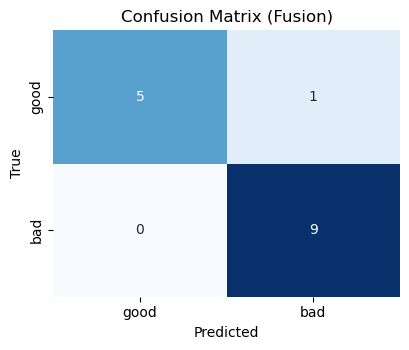

saved figure: confusion_matrix_fusion.png

=== 最终特征选择结果（单模型, k<=10）===
特征集 'big':
  - 最佳模型: svc
  - 保留特征数: 8 个
  - 测试集 F1: 0.889
  - 选中特征（按 MI 排序）:
    * big_f_bp_2000_5000__meanch   MI=0.445910
    * big_tf_stft_10000_20000_mean__meanch   MI=0.429957
    * big_tf_stft_2000_5000_mean__meanch   MI=0.424074
    * big_tf_stft_10000_20000_std__meanch   MI=0.374284
    * big_w_wav_E_L2__meanch   MI=0.371965
    * big_w_wav_E_L3__meanch   MI=0.355374
    * big_tf_stft_5000_10000_std__meanch   MI=0.332618
    * big_f_bp_10000_20000__meanch   MI=0.323300
特征集 'small':
  - 最佳模型: svc
  - 保留特征数: 10 个
  - 测试集 F1: 0.889
  - 选中特征（按 MI 排序）:
    * small_tf_stft_2000_5000_mean__meanch   MI=0.430511
    * small_tf_stft_2000_5000_std__meanch   MI=0.402562
    * small_w_wav_E_L4__meanch   MI=0.358791
    * small_tf_stft_10000_20000_std__meanch   MI=0.291552
    * small_f_bp_2000_5000__meanch   MI=0.287705
    * small_tf_stft_10000_20000_mean__meanch   MI=0.284493
    * small_f_rolloff_85__meanch   MI=0.260

In [ ]:
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# ==============================================================
# 产出与可视化
# - 导出特征表 CSV（若文件被占用则自动另存新文件名）
# - 保存最佳单模型（全特征）
# - 保存融合模型组件（大端/小端模型 + alpha）
# - 绘制并保存融合测试集混淆矩阵LL
# - 打印“10个以内关键特征”列表（单模型 + 融合），并附带：
#   * 互信息分数（MI）
#   * RF 的 feature_importances_ 排名
# ==============================================================

OUT_DIR = DATA_DIR / 'outputs'
OUT_DIR.mkdir(parents=True, exist_ok=True)
print('outputs dir:', OUT_DIR)


def _safe_save_csv(df: pd.DataFrame, path: Path):
    """保存 CSV；若目标文件被占用（PermissionError），则自动另存带时间戳的新文件名。"""
    try:
        df.to_csv(path, index=False, encoding='utf-8-sig')
        print('saved CSV:', path.name)
        return path
    except PermissionError:
        stamp = datetime.now().strftime('%Y%m%d_%H%M%S')
        alt = path.with_name(f"{path.stem}_{stamp}{path.suffix}")
        df.to_csv(alt, index=False, encoding='utf-8-sig')
        print(f"PermissionError: {path.name} 被占用，已另存为 {alt.name}")
        return alt


def _print_feature_list_with_mi(selected_features, mi_scores, max_items: int = 10):
    if not selected_features:
        print("    (无)")
        return

    # 按 MI 从高到低输出（更直观）
    items = []
    for f in selected_features:
        s = None if mi_scores is None else mi_scores.get(f, None)
        items.append((f, float(s) if s is not None else None))

    items.sort(key=lambda x: (-x[1] if x[1] is not None else float('-inf'), x[0]))
    for f, s in items[:max_items]:
        if s is None:
            print(f"    * {f}")
        else:
            print(f"    * {f}   MI={s:.6f}")


def _print_rf_importances(rf_importances, max_items: int = 10):
    if not rf_importances:
        print("    (无)")
        return
    for f, imp in rf_importances[:max_items]:
        print(f"    * {f}   importance={imp:.6f}")


# 1) 导出特征表（含标签与样本ID）
meta = pd.DataFrame({'id': sample_ids, 'y': y})

# 为避免列名冲突，这里分别加前缀再合并
feat_big = pd.concat([meta, X_big.add_prefix('big__')], axis=1)
feat_small = pd.concat([meta, X_small.add_prefix('small__')], axis=1)
feat_all = pd.concat([meta, X_all], axis=1)

_safe_save_csv(feat_big, OUT_DIR / 'features_big.csv')
_safe_save_csv(feat_small, OUT_DIR / 'features_small.csv')
_safe_save_csv(feat_all, OUT_DIR / 'features_all.csv')

# 2) 保存最佳单模型（这里用 all 的最佳模型）
best_all = best_models['all']['best_estimator']
best_all.fit(X_all.iloc[train_idx], y_train)
joblib.dump(best_all, OUT_DIR / 'model_best_all.joblib')
print('saved model:', 'model_best_all.joblib')

# 3) 保存融合模型所需组件（大端、小端模型 + alpha + 元信息）
fusion_bundle = {
    'alpha': best_alpha,
    'big_model': best_big_est,
    'small_model': best_small_est,
    'fs': FS,
    'bands_hz': BANDS_HZ,
    'feature_big_cols': list(X_big.columns),
    'feature_small_cols': list(X_small.columns),
}
joblib.dump(fusion_bundle, OUT_DIR / 'model_fusion_bundle.joblib')
print('saved fusion bundle:', 'model_fusion_bundle.joblib')

# 4) 绘制并保存测试集混淆矩阵（融合结果）
cm = confusion_matrix(y_test, pred_test)
plt.figure(figsize=(4.2, 3.6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['good', 'bad'], yticklabels=['good', 'bad'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (Fusion)')
plt.tight_layout()
plt.savefig(OUT_DIR / 'confusion_matrix_fusion.png', dpi=200)
plt.show()
print('saved figure:', 'confusion_matrix_fusion.png')

# 5) 打印每个特征集的最终选择结果（k<=10），附 MI / RF importance
print("\n=== 最终特征选择结果（单模型, k<=10）===")
for name, data in best_models.items():
    k_value = data['best_params'].get('fs__k', None)
    model_name = data['model']
    score = data['test_f1']
    feats = data.get('selected_features', None)
    mi_scores = data.get('mi_scores', None)
    rf_imps = data.get('rf_importances', None)

    print(f"特征集 '{name}':")
    print(f"  - 最佳模型: {model_name}")
    print(f"  - 保留特征数: {k_value} 个")
    print(f"  - 测试集 F1: {score:.3f}")

    print("  - 选中特征（按 MI 排序）:")
    _print_feature_list_with_mi(feats, mi_scores, max_items=20)

    if model_name == 'rf':
        print("  - RF 特征重要性（importance 排序）:")
        _print_rf_importances(rf_imps, max_items=20)

# 6) 融合关键特征（按 alpha 加权）
#    融合本质是概率加权，因此解释上：big 的关键特征影响权重为 alpha；small 为 1-alpha。
print("\n=== 融合关键特征（按 alpha 加权）===")
print(f"alpha = {best_alpha:.2f}  (big 权重),  {1 - best_alpha:.2f}  (small 权重)")

big_data = best_models.get('big', {})
small_data = best_models.get('small', {})

big_feats = big_data.get('selected_features', None)
small_feats = small_data.get('selected_features', None)

if not big_feats or not small_feats:
    print("无法输出融合关键特征：big/small 的 selected_features 未记录（请先重新运行训练单元格）。")
else:
    fusion_feat_weights = {}
    for f in big_feats:
        fusion_feat_weights[str(f)] = fusion_feat_weights.get(str(f), 0.0) + float(best_alpha)
    for f in small_feats:
        fusion_feat_weights[str(f)] = fusion_feat_weights.get(str(f), 0.0) + float(1 - best_alpha)

    fusion_sorted = sorted(fusion_feat_weights.items(), key=lambda x: (-x[1], x[0]))
    print(f"融合关键特征总数: {len(fusion_sorted)} (通常为 big_k + small_k)")
    for feat, w in fusion_sorted:
        src = 'big' if feat.startswith('big_') else ('small' if feat.startswith('small_') else 'mixed')
        print(f"  * [{src}] weight={w:.2f}  {feat}")


# 方法章节（开题报告风格）

## 1. 数据来源与采集说明

本研究使用敲击响应信号对禽蛋进行二分类（正常蛋 vs 裂纹蛋）。数据存放于 `good/` 与 `bad/` 文件夹中：
- `good/`：正常蛋，共 30 个样本（每个样本对应一个 `.xlsx` 文件）
- `bad/`：裂纹蛋，共 43 个样本（每个样本对应一个 `.xlsx` 文件）

每个 `.xlsx` 文件记录同一个鸡蛋在两端敲击下的响应序列，数据结构约定如下：
- 共 4 列波形数据，且无表头（读取时使用 `header=None`）
- 前 2 列为**大端敲击**两个通道响应，后 2 列为**小端敲击**两个通道响应
- 采样频率 $f_s=48\,\text{kHz}$；每个样本长度为 4800 点（约 0.1 s）

## 2. 预处理与数据组织

为降低传感器直流偏置影响，对每个通道波形做零均值处理：
$$x \leftarrow x - \bar{x}$$

随后分别对大端（2 通道）与小端（2 通道）提取特征，并形成三种特征集用于对比：
- **Big**：仅大端特征（本次维度 74）
- **Small**：仅小端特征（本次维度 74）
- **All**：大端 + 小端拼接（本次维度 148）

## 3. 特征提取（时域、频域、时频域）

考虑样本量约 73，直接使用端到端深度网络容易过拟合，因此采用“信号特征工程 + 传统机器学习”路线。特征从时域、频域与时频域三方面构建：

### 3.1 时域特征（Time Domain）

对每个通道提取：
- 均值、标准差
- 均方根 RMS、峰值（max|x|）、峰峰值（ptp）
- 偏度、峭度
- 过零率（ZCR）
- 波峰因子（crest = peak / RMS）
- 能量 $\sum x^2$

### 3.2 频域特征（Frequency Domain）

使用 Welch 方法估计功率谱密度（PSD）：
- 谱质心（spectral centroid）
- 谱带宽（spectral bandwidth）
- 谱熵（spectral entropy）
- 主频（dominant frequency）
- 85% 频谱滚降点（rolloff_85）
- 分段频带能量（带功率，积分 PSD）：
  - 0–500 Hz、500–2 kHz、2–5 kHz、5–10 kHz、10–20 kHz

### 3.3 时频域特征（Time–Frequency Domain）

采用 STFT 得到时频幅值谱 $|Z(f,t)|$，并对其统计：
- STFT 幅值均值、标准差
- 分段频带（同上频带划分）的 STFT 幅值均值/标准差

### 3.4 小波能量特征（Wavelet Energy）

为了补充短时冲击信号的多尺度表征，引入离散小波变换（db4，小波分解层数最多取 4 层或由数据长度自适应）：
- 各层系数能量 $E_i=\sum c_i^2$

### 3.5 双通道汇总策略

每端敲击含 2 个通道。为提高鲁棒性并降低通道差异带来的方差，对两通道提取同构特征后进行汇总：
- 对每个特征在两通道上取均值（meanch）与标准差（stdch）
- 最终得到每端一套稳定特征向量

## 4. 特征筛选与降维策略

考虑特征维度相对样本量偏高，本研究在模型管线中进行特征筛选：
- 对 SVM 模型：`StandardScaler` 标准化 + `SelectKBest(mutual_info_classif)` 进行单变量筛选
- 对 RandomForest：使用同样的 `SelectKBest(mutual_info_classif)` 先做特征子集选择，再训练分类器
- `k` 取值根据维度自适应候选（本实验用 20/40/60，并保证不超过总维度）

## 5. 模型选择与训练（依据数据量）

### 5.1 选型依据

当前数据量约 73 个样本，属于小样本场景：
- 优先选择对小样本更稳健的传统模型（SVM、随机森林），并通过交叉验证选择超参
- 深度学习模型（CNN/RNN/Transformer）需要更多样本或强正则/数据增强，否则风险较高
- 本研究以可解释、可复现为目标，采用 scikit-learn 管线实现

### 5.2 训练与验证设置

- 划分：按类别分层的 8:2 训练/测试划分（固定随机种子）
- 训练集内：5 折分层交叉验证（StratifiedKFold）
- 评价指标：以 **F1-score** 为主（兼顾 Precision/Recall），并输出 Accuracy 与混淆矩阵

### 5.3 模型与超参搜索

对每个特征集（Big/Small/All）分别进行网格搜索（GridSearchCV）：
- SVM（RBF）：$C \in \{1,10,100\}$，$\gamma \in \{\text{scale},\text{auto}\}$，并搜索 `k`
- RandomForest：`n_estimators` \in {200, 400}，`max_depth` \in {None, 10, 20}，并搜索 `k`

## 6. 创新点：两端敲击多视角加权融合（Soft Voting with Alpha Search）

裂纹与正常在大端/小端敲击下可能呈现不同的响应差异。为利用两端信息互补性，本研究提出**两端多视角加权融合**：
1. 分别在大端特征与小端特征上训练两个概率输出模型（本实验最佳均为 RandomForest）
2. 对于样本的裂纹概率，使用加权融合：
$$p = \alpha\,p_{big} + (1-\alpha)\,p_{small},\quad \alpha\in[0,1]$$
3. 在训练集上通过 5 折交叉验证得到 out-of-fold 概率，遍历 $\alpha\in\{0,0.1,\dots,1.0\}$ 选择使训练集 F1 最大的 $\alpha$
4. 最终在测试集上评估融合分类器

该创新点的优点：
- 不需要引入复杂的深度结构即可融合两端信息
- 通过交叉验证自动确定权重，避免人工经验设置
- 对小样本场景更友好，易解释、易复现

## 7. 指标与本次实验结果（简述）

### 7.1 指标定义

- Accuracy：$\frac{TP+TN}{TP+TN+FP+FN}$
- Precision：$\frac{TP}{TP+FP}$
- Recall：$\frac{TP}{TP+FN}$
- F1-score：$\frac{2\cdot Precision\cdot Recall}{Precision+Recall}$

### 7.2 本次实验设置与结果

- 数据规模：73（正常 30，裂纹 43）
- 特征维度：Big 74、Small 74、All 148
- 融合权重：本次训练集 CV 搜索得到 $\alpha=0.60$
- 测试集（15 个样本）融合混淆矩阵：
  - good: 6/6 正确；bad: 9/9 正确（Accuracy=1.0, F1=1.0）

说明：上述结果基于一次固定随机种子的分层划分。为在论文/开题中更稳健地呈现性能，建议在后续补充：重复分层 K 折（RepeatedStratifiedKFold）或多次随机划分的均值±方差。

## 8. 可复现性与产出文件

已在 `outputs/` 导出：
- `features_big.csv`、`features_small.csv`、`features_all.csv`（含样本 id 与标签 y）
- `model_best_all.joblib`（拼接特征最佳单模型）
- `model_fusion_bundle.joblib`（融合模型组件：big/small 模型 + alpha）
- `confusion_matrix_fusion.png`（融合结果混淆矩阵图）